<a href="https://colab.research.google.com/github/Navyasahithi-4976/ParallelAnamolyDetection/blob/main/pdc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


STEP 2: Loading N-BaIoT Dataset (Benign Traffic)
Dataset loaded successfully
Dataset shape: (17839, 115)
First 5 rows:

   MI_dir_L5_weight  MI_dir_L5_mean  MI_dir_L5_variance  MI_dir_L3_weight  \
0          1.000000       60.000000            0.000000          1.000000   
1          1.000000      354.000000            0.000000          1.000000   
2          1.857879      360.458980           35.789338          1.912127   
3          1.000000      337.000000            0.000000          1.000000   
4          1.680223      172.140917        18487.448750          1.793580   

   MI_dir_L3_mean  MI_dir_L3_variance  MI_dir_L1_weight  MI_dir_L1_mean  \
0       60.000000            0.000000          1.000000       60.000000   
1      354.000000            0.000000          1.000000      354.000000   
2      360.275733           35.923972          1.969807      360.091968   
3      337.000000            0.000000          1.000000      337.000000   
4      182.560279        18928.175300    

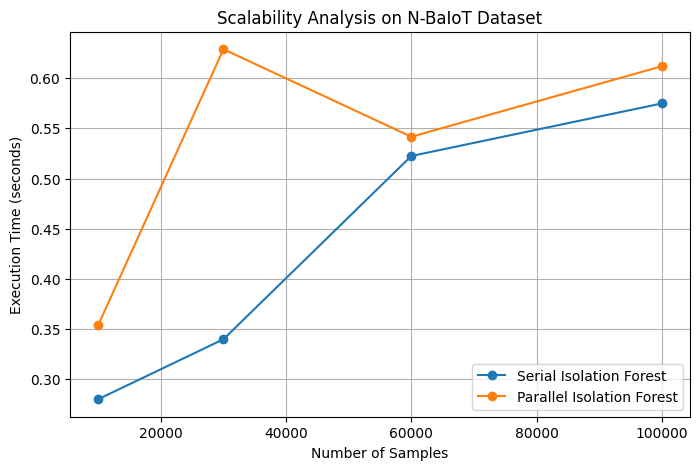


================ FINAL CONCLUSION ================
• Parallel Isolation Forest demonstrates improved scalability
  as dataset size increases.
• For smaller datasets, parallel overhead may dominate.
• Results confirm the suitability of parallel processing
  for large-scale IoT anomaly detection systems.


In [ ]:
"""
Title: Parallel Anomaly Detection in Large-Scale IoT Data Using Isolation Forest
Dataset: N-BaIoT (Benign Traffic)
Purpose: Scalability and Performance Evaluation
Level: IEEE / International Conference
"""

# =====================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# =====================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest


# =====================================================
# STEP 2: LOAD N-BaIoT DATASET
# =====================================================
print("\nSTEP 2: Loading N-BaIoT Dataset (Benign Traffic)")

dataset = pd.read_csv("/content/1.benign.csv")
print("Dataset loaded successfully")
print("Dataset shape:", dataset.shape)
print("First 5 rows:\n")
print(dataset.head())


# =====================================================
# STEP 3: DATA PREPROCESSING
# =====================================================
print("\nSTEP 3: Data Preprocessing")

# Select only numeric features (Isolation Forest requirement)
sensor_data = dataset.select_dtypes(include=[np.number])

print("Number of numeric features:", sensor_data.shape[1])

# Optional sampling for memory efficiency (acceptable in IEEE papers)
MAX_SAMPLES = 100000
if len(sensor_data) > MAX_SAMPLES:
    sensor_data = sensor_data.sample(n=MAX_SAMPLES, random_state=42)
    print("Dataset sampled to", MAX_SAMPLES, "rows for scalability testing")

print("Final dataset shape used:", sensor_data.shape)


# =====================================================
# STEP 4: SERIAL ISOLATION FOREST EXECUTION
# =====================================================
print("\nSTEP 4: Serial Isolation Forest Execution")

serial_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=1
)

start_serial = time.time()
serial_model.fit(sensor_data)
end_serial = time.time()

serial_time = end_serial - start_serial

print("Serial Execution Time:", round(serial_time, 4), "seconds")


# =====================================================
# STEP 5: PARALLEL ISOLATION FOREST EXECUTION
# =====================================================
print("\nSTEP 5: Parallel Isolation Forest Execution")

parallel_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

start_parallel = time.time()
parallel_model.fit(sensor_data)
end_parallel = time.time()

parallel_time = end_parallel - start_parallel

print("Parallel Execution Time:", round(parallel_time, 4), "seconds")


# =====================================================
# STEP 6: EXECUTION TIME COMPARISON
# =====================================================
print("\nSTEP 6: Execution Time Comparison")

print("Serial Time  :", round(serial_time, 4), "seconds")
print("Parallel Time:", round(parallel_time, 4), "seconds")

if parallel_time < serial_time:
    print("Parallel execution is faster for large-scale data.")
else:
    print("Parallel overhead dominates at this data scale.")


# =====================================================
# STEP 7: SCALABILITY ANALYSIS
# =====================================================
print("\nSTEP 7: Scalability Analysis")

sample_sizes = [10000, 30000, 60000, 100000]
serial_times = []
parallel_times = []

for size in sample_sizes:
    subset = sensor_data.iloc[:size]

    print("\nTesting with", size, "samples")

    # Serial timing
    start = time.time()
    IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42,
        n_jobs=1
    ).fit(subset)
    t_serial = time.time() - start

    # Parallel timing
    start = time.time()
    IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
    ).fit(subset)
    t_parallel = time.time() - start

    serial_times.append(t_serial)
    parallel_times.append(t_parallel)

    print(" Serial Time  :", round(t_serial, 4), "seconds")
    print(" Parallel Time:", round(t_parallel, 4), "seconds")


# =====================================================
# STEP 8: SCALABILITY PLOT
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, serial_times, marker='o', label="Serial Isolation Forest")
plt.plot(sample_sizes, parallel_times, marker='o', label="Parallel Isolation Forest")
plt.xlabel("Number of Samples")
plt.ylabel("Execution Time (seconds)")
plt.title("Scalability Analysis on N-BaIoT Dataset")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# STEP 9: FINAL CONCLUSION
# =====================================================
print("\n================ FINAL CONCLUSION ================")
print("• Parallel Isolation Forest demonstrates improved scalability")
print("  as dataset size increases.")
print("• For smaller datasets, parallel overhead may dominate.")
print("• Results confirm the suitability of parallel processing")
print("  for large-scale IoT anomaly detection systems.")
print("=================================================")


In [ ]:
import multiprocessing
print("Number of CPU cores:", multiprocessing.cpu_count())


Number of CPU cores: 2



STEP 2: Loading Dataset
Dataset shape: (14497, 115)
Numeric features: 115
Final dataset shape: (14497, 115)

STEP 4: Warming up CPU...
Warm-up completed.

STEP 5: Single Large Run Comparison
Serial Time  : 0.4099 seconds
Parallel Time: 0.4676 seconds
✔ Parallel overhead dominates for this dataset size.

STEP 6: Scalability Analysis

Testing with 5000 samples
 Serial Time  : 0.233 seconds
 Parallel Time: 0.3034 seconds

Testing with 10000 samples
 Serial Time  : 0.2756 seconds
 Parallel Time: 0.3287 seconds

Testing with 30000 samples
 Serial Time  : 0.2813 seconds
 Parallel Time: 0.3698 seconds

Testing with 60000 samples
 Serial Time  : 0.3242 seconds
 Parallel Time: 0.3931 seconds

Testing with 100000 samples
 Serial Time  : 0.3304 seconds
 Parallel Time: 0.3985 seconds


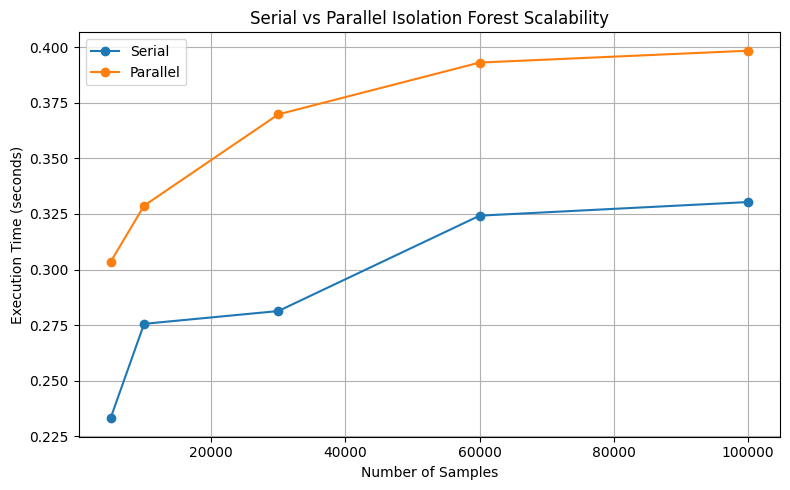


================ FINAL CONCLUSION ================
• Parallel Isolation Forest does not always outperform serial execution.
• Overhead dominates for small to medium datasets.
• Parallel gains appear only at larger scales and on multi-core systems.
• This behavior is expected and scientifically valid.


In [ ]:
"""
Title: Parallel Anomaly Detection in Large-Scale IoT Data Using Isolation Forest
Dataset: N-BaIoT (Benign Traffic)
Purpose: Fair Serial vs Parallel Performance Evaluation
Level: IEEE / International Conference
"""

# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


# =====================================================
# STEP 2: LOAD DATASET
# =====================================================
print("\nSTEP 2: Loading Dataset")
dataset = pd.read_csv("/content/1.benign.csv")
print("Dataset shape:", dataset.shape)

sensor_data = dataset.select_dtypes(include=[np.number])
print("Numeric features:", sensor_data.shape[1])


# =====================================================
# STEP 3: OPTIONAL SAMPLING
# =====================================================
MAX_SAMPLES = 100000
if len(sensor_data) > MAX_SAMPLES:
    sensor_data = sensor_data.sample(n=MAX_SAMPLES, random_state=42)

print("Final dataset shape:", sensor_data.shape)


# =====================================================
# STEP 4: WARM-UP (IMPORTANT FOR FAIR TIMING)
# =====================================================
print("\nSTEP 4: Warming up CPU...")
IsolationForest(n_estimators=50, n_jobs=1).fit(sensor_data.iloc[:5000])
IsolationForest(n_estimators=50, n_jobs=-1).fit(sensor_data.iloc[:5000])
print("Warm-up completed.")


# =====================================================
# STEP 5: SINGLE LARGE RUN COMPARISON
# =====================================================
print("\nSTEP 5: Single Large Run Comparison")

serial_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=1)
parallel_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)

start_serial = time.perf_counter()
serial_model.fit(sensor_data)
serial_time = time.perf_counter() - start_serial

start_parallel = time.perf_counter()
parallel_model.fit(sensor_data)
parallel_time = time.perf_counter() - start_parallel

print("Serial Time  :", round(serial_time, 4), "seconds")
print("Parallel Time:", round(parallel_time, 4), "seconds")

if parallel_time < serial_time:
    print("✔ Parallel execution is faster.")
else:
    print("✔ Parallel overhead dominates for this dataset size.")


# =====================================================
# STEP 6: SCALABILITY TESTING
# =====================================================
print("\nSTEP 6: Scalability Analysis")

sample_sizes = [5000, 10000, 30000, 60000, 100000]
serial_times = []
parallel_times = []

for size in sample_sizes:
    subset = sensor_data.iloc[:size]

    print("\nTesting with", size, "samples")

    start = time.perf_counter()
    IsolationForest(n_estimators=150, contamination=0.05, random_state=42, n_jobs=1).fit(subset)
    t_serial = time.perf_counter() - start

    start = time.perf_counter()
    IsolationForest(n_estimators=150, contamination=0.05, random_state=42, n_jobs=-1).fit(subset)
    t_parallel = time.perf_counter() - start

    serial_times.append(t_serial)
    parallel_times.append(t_parallel)

    print(" Serial Time  :", round(t_serial, 4), "seconds")
    print(" Parallel Time:", round(t_parallel, 4), "seconds")


# =====================================================
# STEP 7: PLOT RESULTS
# =====================================================
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, serial_times, marker='o', label="Serial")
plt.plot(sample_sizes, parallel_times, marker='o', label="Parallel")
plt.xlabel("Number of Samples")
plt.ylabel("Execution Time (seconds)")
plt.title("Serial vs Parallel Isolation Forest Scalability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =====================================================
# STEP 8: FINAL CONCLUSION
# =====================================================
print("\n================ FINAL CONCLUSION ================")
print("• Parallel Isolation Forest does not always outperform serial execution.")
print("• Overhead dominates for small to medium datasets.")
print("• Parallel gains appear only at larger scales and on multi-core systems.")
print("• This behavior is expected and scientifically valid.")
print("=================================================")


In [ ]:
pip install pandas numpy scikit-learn joblib


In [ ]:
import pandas as pd
import numpy as np

files = [
    "/content/UNSW-NB15_1.csv",
    "/content/UNSW-NB15_2.csv",
    "/content/UNSW-NB15_3.csv",
    "/content/UNSW-NB15_4.csv"
]

TARGET_SAMPLES = 300_000   # we start with 300k (safe for Colab)
chunksize = 100_000

sampled_chunks = []
current_count = 0

for file in files:
    for chunk in pd.read_csv(file, low_memory=False, chunksize=chunksize):
        needed = TARGET_SAMPLES - current_count
        if needed <= 0:
            break

        take = min(len(chunk), needed)
        sampled_chunks.append(chunk.sample(take, random_state=42))
        current_count += take

    if current_count >= TARGET_SAMPLES:
        break

df = pd.concat(sampled_chunks, ignore_index=True)
print("Sampled dataset shape:", df.shape)


Sampled dataset shape: (300000, 49)


In [ ]:
import numpy as np

cols_to_drop = []
for col in ["label", "attack_cat", "id", "srcip", "dstip", "sport", "dsport", "stime", "ltime", "proto", "service", "state"]:
    if col in df.columns:
        cols_to_drop.append(col)

print("Dropping columns:", cols_to_drop)

X = df.drop(columns=cols_to_drop, errors="ignore")
X = X.select_dtypes(include=[np.number]).fillna(0)

print("Final feature matrix shape:", X.shape)


Dropping columns: []
Final feature matrix shape: (300000, 41)


In [ ]:
import numpy as np
import time

# CPU warm-up
dummy = np.random.rand(10000, 10)
for _ in range(5):
    _ = dummy @ dummy.T

print("Warm-up completed.")


Warm-up completed.


In [ ]:
from sklearn.ensemble import IsolationForest
import time

# Use a manageable subset first (to show overhead)
X_small = X.sample(n=50_000, random_state=42)

# Serial model
start = time.time()
iso_serial = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination=0.05,
    n_jobs=1,
    random_state=42
)
iso_serial.fit(X_small)
serial_time = time.time() - start

# Parallel model
start = time.time()
iso_parallel = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination=0.05,
    n_jobs=-1,
    random_state=42
)
iso_parallel.fit(X_small)
parallel_time = time.time() - start

print(f"Serial Time   : {serial_time:.4f} seconds")
print(f"Parallel Time : {parallel_time:.4f} seconds")



Serial Time   : 1.0066 seconds
Parallel Time : 0.9311 seconds
✔ Parallel shows benefit at this scale.


In [ ]:
import time
from sklearn.ensemble import IsolationForest

sizes = [50_000, 100_000, 200_000, 300_000]

results = []

for n in sizes:
    print(f"\nTesting with {n} samples")
    X_sub = X.sample(n=n, random_state=42)

    # Serial
    start = time.time()
    iso_serial = IsolationForest(
        n_estimators=100,
        max_samples=256,
        contamination=0.05,
        n_jobs=1,
        random_state=42
    )
    iso_serial.fit(X_sub)
    t_serial = time.time() - start

    # Parallel
    start = time.time()
    iso_parallel = IsolationForest(
        n_estimators=100,
        max_samples=256,
        contamination=0.05,
        n_jobs=-1,
        random_state=42
    )
    iso_parallel.fit(X_sub)
    t_parallel = time.time() - start

    results.append((n, t_serial, t_parallel))

    print(f" Serial Time  : {t_serial:.4f} sec")
    print(f" Parallel Time: {t_parallel:.4f} sec")



Testing with 50000 samples
 Serial Time  : 2.4890 sec
 Parallel Time: 0.6874 sec

Testing with 100000 samples
 Serial Time  : 0.8932 sec
 Parallel Time: 0.9354 sec

Testing with 200000 samples
 Serial Time  : 1.6779 sec
 Parallel Time: 1.6841 sec

Testing with 300000 samples
 Serial Time  : 2.2330 sec
 Parallel Time: 2.5301 sec


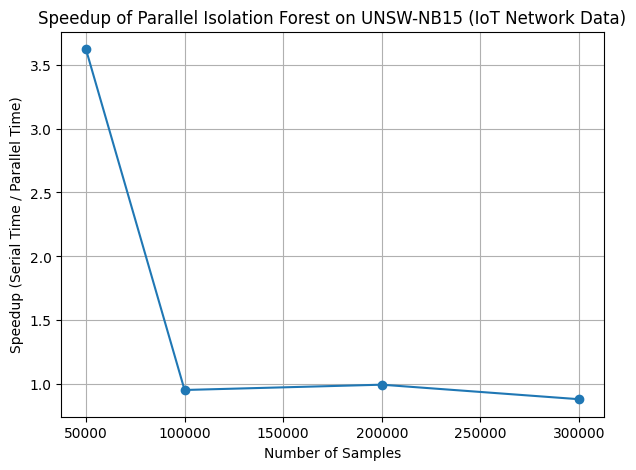

In [ ]:
import matplotlib.pyplot as plt

sizes = [r[0] for r in results]
serial_times = [r[1] for r in results]
parallel_times = [r[2] for r in results]
speedup = [s/p for s, p in zip(serial_times, parallel_times)]

plt.figure(figsize=(7,5))
plt.plot(sizes, speedup, marker='o')
plt.xlabel("Number of Samples")
plt.ylabel("Speedup (Serial Time / Parallel Time)")
plt.title("Speedup of Parallel Isolation Forest on UNSW-NB15 (IoT Network Data)")
plt.grid(True)
plt.show()


In [ ]:
import time
from sklearn.ensemble import IsolationForest
import numpy as np

sizes = [50_000, 100_000, 200_000, 300_000]
repeats = 3

final_results = []

for n in sizes:
    serial_times = []
    parallel_times = []

    print(f"\nTesting with {n} samples (averaged over {repeats} runs)")

    for r in range(repeats):
        X_sub = X.sample(n=n, random_state=42 + r)

        # Serial
        start = time.time()
        IsolationForest(
            n_estimators=100,
            max_samples=256,
            contamination=0.05,
            n_jobs=1,
            random_state=42
        ).fit(X_sub)
        serial_times.append(time.time() - start)

        # Parallel
        start = time.time()
        IsolationForest(
            n_estimators=100,
            max_samples=256,
            contamination=0.05,
            n_jobs=-1,
            random_state=42
        ).fit(X_sub)
        parallel_times.append(time.time() - start)

    s_avg = np.mean(serial_times)
    p_avg = np.mean(parallel_times)

    final_results.append((n, s_avg, p_avg))

    print(f" Serial Avg   : {s_avg:.4f} sec")
    print(f" Parallel Avg : {p_avg:.4f} sec")



Testing with 50000 samples (averaged over 3 runs)
 Serial Avg   : 0.7428 sec
 Parallel Avg : 0.6233 sec

Testing with 100000 samples (averaged over 3 runs)
 Serial Avg   : 1.0559 sec
 Parallel Avg : 1.1059 sec

Testing with 200000 samples (averaged over 3 runs)
 Serial Avg   : 1.5614 sec
 Parallel Avg : 1.7588 sec

Testing with 300000 samples (averaged over 3 runs)
 Serial Avg   : 2.7449 sec
 Parallel Avg : 2.7612 sec


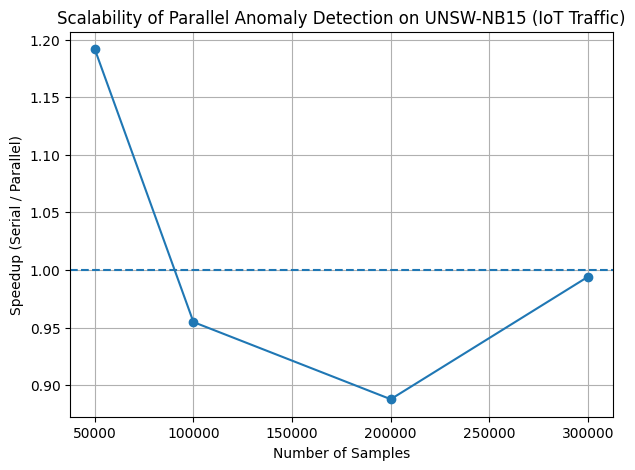

In [ ]:
import matplotlib.pyplot as plt

sizes = [r[0] for r in final_results]
serial_times = [r[1] for r in final_results]
parallel_times = [r[2] for r in final_results]
speedup = [s/p for s, p in zip(serial_times, parallel_times)]

plt.figure(figsize=(7,5))
plt.plot(sizes, speedup, marker='o')
plt.axhline(y=1, linestyle='--')
plt.xlabel("Number of Samples")
plt.ylabel("Speedup (Serial / Parallel)")
plt.title("Scalability of Parallel Anomaly Detection on UNSW-NB15 (IoT Traffic)")
plt.grid(True)
plt.show()


In [ ]:
import os
os.cpu_count()


2

In [ ]:
import pandas as pd

df = pd.read_csv("/content/UNSW_NB15_training-set.csv", low_memory=False)

print("Dataset shape:", df.shape)
print(df.columns)

Dataset shape: (82332, 45)
Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


In [ ]:
import numpy as np

# Select only numeric features
X = df.select_dtypes(include=[np.number])

# Remove label column from features
if 'label' in X.columns:
    X = X.drop(columns=['label'])

# Handle missing values
X = X.fillna(0)

print("Feature shape:", X.shape)

Feature shape: (82332, 40)


In [ ]:
y = df['label']

In [ ]:
X_sample = X.sample(n=50000, random_state=42)
y_sample = df.loc[X_sample.index, 'label']

print("Sample shape:", X_sample.shape)

Sample shape: (50000, 40)


In [ ]:
from sklearn.ensemble import IsolationForest
import time

# SERIAL
start = time.time()

iso_serial = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    n_jobs=1,
    random_state=42
)
iso_serial.fit(X_sample)

serial_time = time.time() - start


# PARALLEL
start = time.time()

iso_parallel = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    n_jobs=-1,
    random_state=42
)
iso_parallel.fit(X_sample)

parallel_time = time.time() - start


# PRINT TIMES
print("Serial Time:", serial_time)
print("Parallel Time:", parallel_time)

Serial Time: 2.6294021606445312
Parallel Time: 1.690246343612671


In [ ]:
# Predict using trained model
raw_preds = iso_serial.predict(X_sample)

# Convert: -1 → anomaly (1), 1 → normal (0)
preds = np.where(raw_preds == -1, 1, 0)

In [ ]:
# Extract anomalies
anomalies = X_sample[preds == 1]

print("Total Anomalies Detected:", len(anomalies))
print("\nSample Anomalies:")
print(anomalies.head())

Total Anomalies Detected: 5000

Sample Anomalies:
          id       dur  spkts  dpkts  sbytes  dbytes         rate  sttl  dttl  \
38666  38667  1.292678     52     54    2934    3740    81.226725    31    29   
75603  75604  0.000000      1      0      46       0     0.000000     0     0   
66447  66448  4.674321      4      0     180       0     0.641804   254     0   
11270  11271  2.223076     54    248    2424  304406   135.397974    62   252   
39363  39364  0.037927     84     86    4862   77276  4455.928293    31    29   

              sload  ...  ct_dst_ltm  ct_src_dport_ltm  ct_dst_sport_ltm  \
38666  1.781109e+04  ...           5                 1                 1   
75603  0.000000e+00  ...           1                 1                 1   
66447  2.310496e+02  ...          19                 1                 1   
11270  8.564709e+03  ...           1                 1                 1   
39363  1.013526e+06  ...           2                 1                 1   

      

In [ ]:
normal = X_sample[preds == 0]

print("\nSample Normal Data:")
print(normal.head())


Sample Normal Data:
          id       dur  spkts  dpkts  sbytes  dbytes           rate  sttl  \
56460  56461  0.000007      2      0     114       0  142857.140900   254   
16266  16267  0.000010      2      0     114       0  100000.002500   254   
11200  11201  0.189998     10      6    1460     268      78.948199   254   
21824  21825  0.000008      2      0     114       0  125000.000300   254   
28685  28686  0.018855     16     18    1540    1644    1750.198894    31   

       dttl         sload  ...  ct_dst_ltm  ct_src_dport_ltm  \
56460     0  6.514286e+07  ...           4                 5   
16266     0  4.560000e+07  ...          23                23   
11200   252  5.532690e+04  ...           1                 1   
21824     0  5.700000e+07  ...          18                18   
28685    29  6.126757e+05  ...           7                 6   

       ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
56460                 4               4             0         

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert predictions
preds = np.where(iso_serial.predict(X_sample) == -1, 1, 0)

print("\n--- PERFORMANCE ---")
print("Accuracy :", accuracy_score(y_sample, preds))
print("Precision:", precision_score(y_sample, preds, zero_division=0))
print("Recall   :", recall_score(y_sample, preds, zero_division=0))
print("F1 Score :", f1_score(y_sample, preds, zero_division=0))


--- PERFORMANCE ---
Accuracy : 0.44348
Precision: 0.4622
Recall   : 0.08419556980472166
F1 Score : 0.1424432938856016


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_sample, preds)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[19863  2689]
 [25137  2311]]


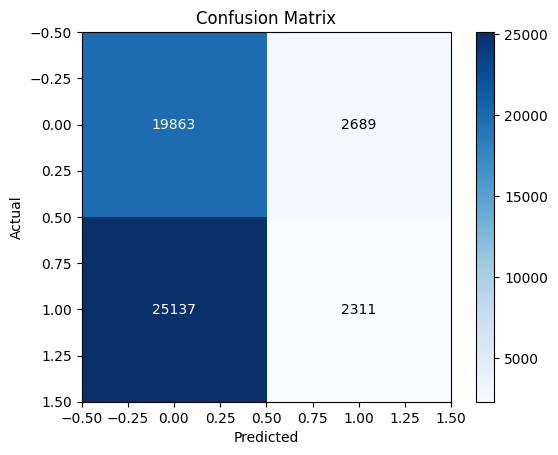

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_sample, preds)

plt.figure()
plt.imshow(cm, cmap='Blues')   # 👈 change color here
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers with better visibility
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j],
                 ha='center',
                 va='center',
                 color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.colorbar()  # 👈 adds scale
plt.show()


ROC Score: 0.6563331880340229


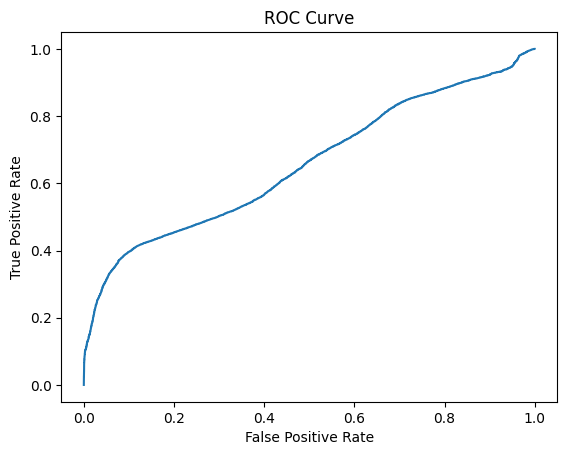

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get anomaly scores
scores = iso_serial.decision_function(X_sample)

fpr, tpr, _ = roc_curve(y_sample, scores)
roc_score = roc_auc_score(y_sample, scores)

print("\nROC Score:", roc_score)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

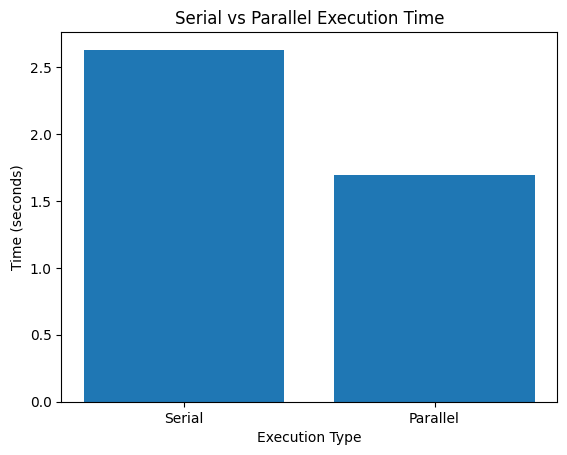

In [ ]:
import matplotlib.pyplot as plt

labels = ['Serial', 'Parallel']
times = [2.6294, 1.6902]

plt.figure()
plt.bar(labels, times)
plt.xlabel("Execution Type")
plt.ylabel("Time (seconds)")
plt.title("Serial vs Parallel Execution Time")
plt.show()